**Credit Card Fraud Detection - By Staries Teke**

**Project Description:**

This project aims to develop a machine learning model to identify fraudulent credit card transactions. Using a publicly available dataset containing anonymized transaction details, the project tackles the challenges of imbalanced data and the need for high precision to minimize false positives. The data science pipeline includes:

**Data Exploration:** Understanding the dataset, analyzing class distribution, and identifying patterns in fraud and non-fraud transactions.

**Preprocessing:** Scaling numerical features, handling missing values, and addressing class imbalance with techniques like SMOTE.

**Exploratory Data Analysis (EDA):** Visualizing feature distributions and identifying strong predictors of fraud.

**Modeling and Tuning:** Implementing a Random Forest classifier, fine-tuning hyperparameters with RandomizedSearchCV, and evaluating performance using precision, recall, and F1-score.

**Evaluation:** Demonstrating the effectiveness of the model in detecting fraud while maintaining a balance between precision and recall.

This project highlights the complexities of fraud detection in real-world applications and provides actionable insights for building robust and scalable fraud detection systems.

1. Download and Explore the Dataset

In [2]:
import pandas as pd
df = pd.read_csv('/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


2. **UNDERSTANDING THE DATA**

**Features:** The dataset contains 31 columns:

**Time:** Time of transaction.

**V1 to V28:** Principal components obtained via PCA (feature names are anonymized).

**Amount:** Transaction amount.

In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


3. **Clean and Preprocess the Data**


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Reload the dataframe to ensure 'Amount' and 'Time' columns are present
df = pd.read_csv('/creditcard.csv')

# Apply StandardScaler and create new columns
df['scaled_amount'] = StandardScaler().fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = StandardScaler().fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original 'Time' and 'Amount' columns
df = df.drop(['Time', 'Amount'], axis=1)

# Display value counts for 'Class' column
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [6]:
import pandas as pd

df = pd.read_csv('/creditcard.csv')

# Apply StandardScaler and create new columns
df['scaled_amount'] = StandardScaler().fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = StandardScaler().fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original 'Time' and 'Amount' columns
df = df.drop(['Time', 'Amount'], axis=1)

# Display value counts for 'Class' column
df['Class'].value_counts()

,count
Class,
0,284315
1,492


4. **Perform Exploratory Data Analysis (EDA)**

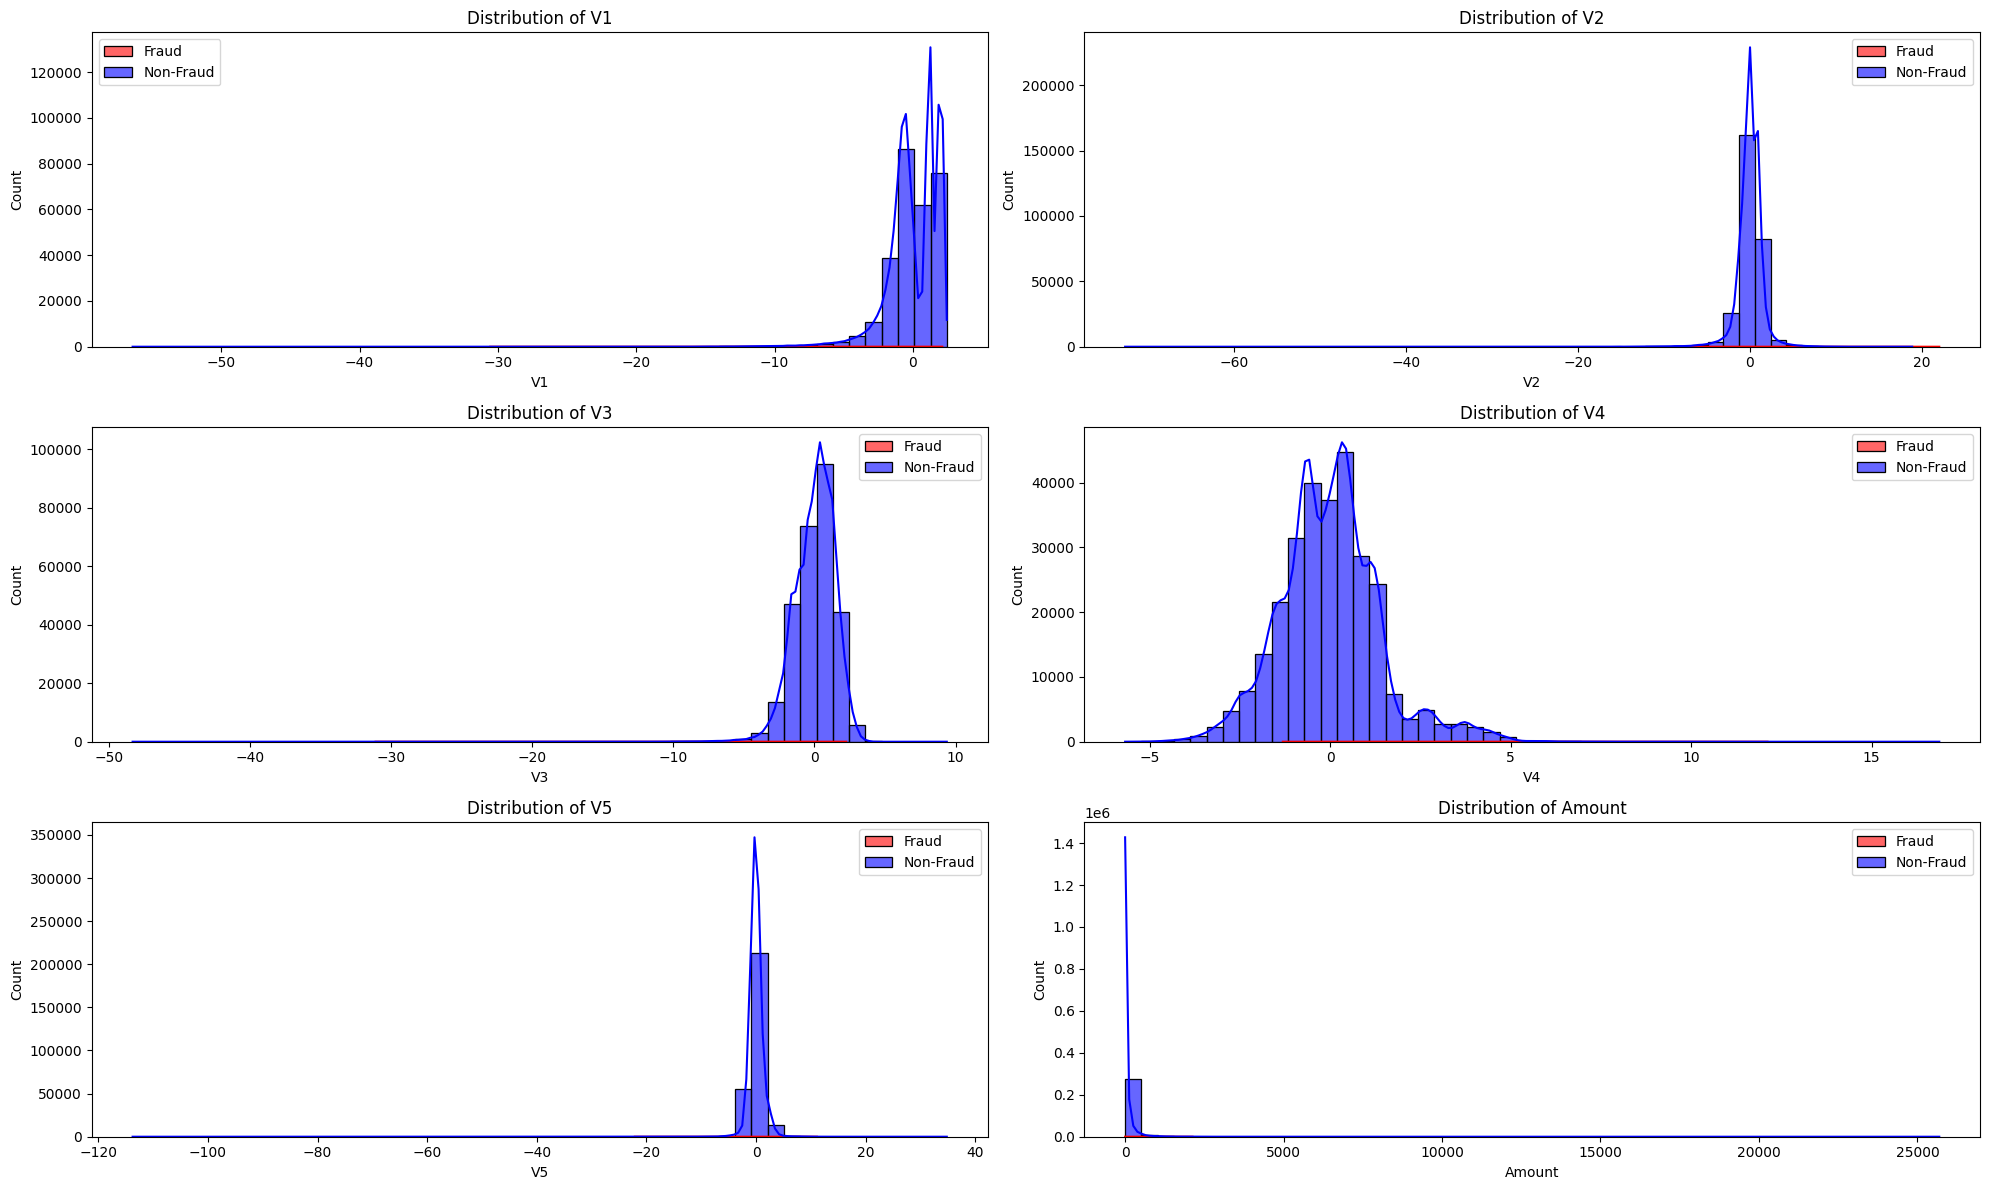

In [7]:
#Visualize the distribution of features for fraud and non-fraud cases
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Separate fraud and non-fraud cases
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]

# Define the features to visualize
features = ['V1', 'V2', 'V3', 'V4', 'V5', 'Amount']

# Set up the matplotlib figure
plt.figure(figsize=(20, 12))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)  # Arrange subplots in a 3x2 grid
    sns.histplot(fraud[feature], bins=50, color='red', kde=True, label='Fraud', alpha=0.6)
    sns.histplot(non_fraud[feature], bins=50, color='blue', kde=True, label='Non-Fraud', alpha=0.6)
    plt.title(f'Distribution of {feature}')
    plt.legend()

plt.tight_layout()
plt.show()




5. **Split the Data**

In [8]:
#Divide the dataset into training and testing subsets:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Split the data into training and testing sets
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)


(227845, 30)
(56962, 30)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



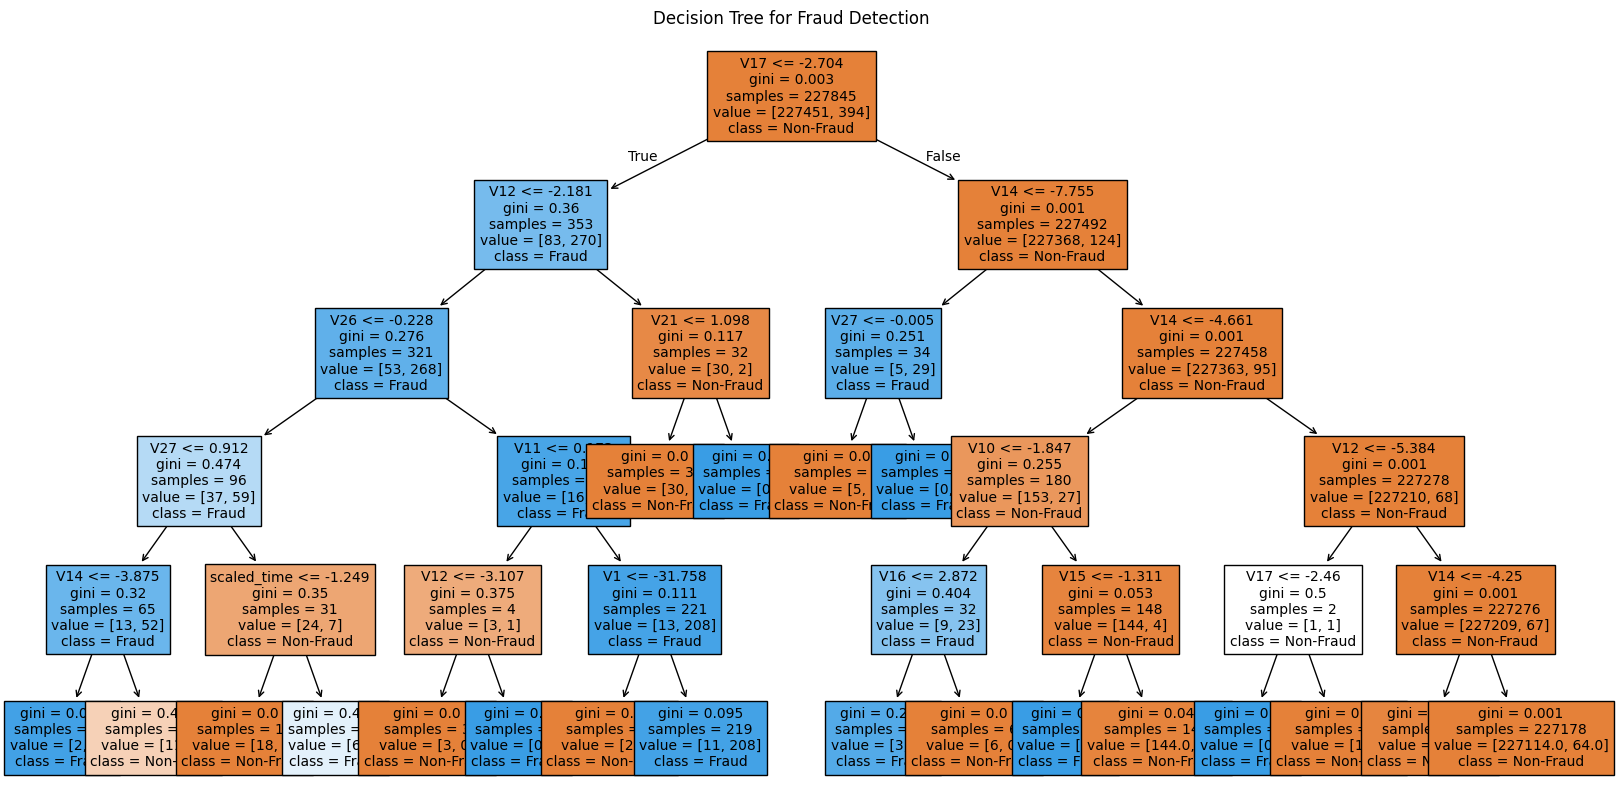

In [9]:
# Decision Tree
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Optional: Scale numerical features (Time and Amount)
from sklearn.preprocessing import StandardScaler
X['scaled_amount'] = StandardScaler().fit_transform(X['Amount'].values.reshape(-1, 1))
X['scaled_time'] = StandardScaler().fit_transform(X['Time'].values.reshape(-1, 1))
X = X.drop(['Time', 'Amount'], axis=1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Evaluate the model
y_pred = dt_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize the Decision Tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Non-Fraud', 'Fraud'], filled=True, fontsize=10)
plt.title("Decision Tree for Fraud Detection")
plt.show()


**Insights from the Tree**

**Dominant Features:**
The tree highlights features like V14, V12, and V10 as critical in identifying fraud.

**Fraud Detection Rules:**
Fraudulent transactions tend to follow specific paths based on feature thresholds.

**Imbalanced Data Handling:**
Decision tree splits reflect the dataset's imbalance, often resulting in more nodes for non-fraud transactions.

6. **Apply Machine Learning Algorithm**

Algorithm: Random Forest





In [10]:
#Train a Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
classification_report(y_test, y_pred)
confusion_matrix(y_test, y_pred)



array([[56859,     5],
       [   18,    80]])

7. **Evaluating Performance**

In [ ]:
# Adjust prediction probabilities
from sklearn.metrics import precision_score # Import precision_score

y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for Class 1 (fraud)
threshold = 0.7  # Set a higher threshold
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

precision_adjusted = precision_score(y_test, y_pred_adjusted)

print(f"Adjusted Precision: {precision_adjusted:.2f}")

Adjusted Precision: 0.97


Looking at the data above, High precision indicates a low rate of false positives. In fraud detection, this ensures that normal transactions are less likely to be flagged as fraud, reducing inconvenience to users.

8. **Optimizing the Model**

In [ ]:
# Using RandomizedSearchCV to improve performance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, precision_score
import numpy as np

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter combinations to try
    scoring='precision',  # Optimize for precision
    cv=3,  # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all processors
)

# Perform the search
random_search.fit(X_train, y_train)

# Output the best parameters
print("Best Parameters:", random_search.best_params_)

# Evaluate the best model
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calculate precision and other metrics
precision = precision_score(y_test, y_pred)
print(f"Precision after hyperparameter tuning: {precision:.2f}")

# Optional: Detailed evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 50 candidates, totalling 150 fits


 **SECOND ALGORITHM: Support Vector Machine**

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train an SVM classifier
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.76      0.45        98

    accuracy                           1.00     56962
   macro avg       0.66      0.88      0.72     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56708   156]
 [   24    74]]


In [ ]:
# Optimization
# Hyperparameter tuning using GridSearchCV
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],              # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001],      # Kernel coefficient
    'kernel': ['linear', 'rbf']          # Kernel type
}

# Initialize the SVM model
svm_model = SVC(class_weight='balanced', random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring='f1',                        # Optimize for F1-score
    cv=3,                                # 3-fold cross-validation
    verbose=2,
    n_jobs=-1                            # Use all available processors
)

# Perform Grid Search
grid_search.fit(X_train, y_train)

# Print the best parameters and the best F1-score
print("Best Parameters:", grid_search.best_params_)
print("Best F1-Score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 32 candidates, totalling 96 fits


In [14]:
# Comparing SVM and Random Forest Algorithms

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import time

# Load the dataset
df = pd.read_csv('/creditcard.csv')

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train SVM
start_svm = time.time()
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)
end_svm = time.time()

# Predictions and evaluation for SVM
y_pred_svm = svm_model.predict(X_test)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)

# Train Random Forest
start_rf = time.time()
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
end_rf = time.time()

# Predictions and evaluation for Random Forest
y_pred_rf = rf_model.predict(X_test)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Print the results
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print(f"SVM Training + Prediction Time: {end_svm - start_svm:.2f} seconds\n")

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"Random Forest Training + Prediction Time: {end_rf - start_rf:.2f} seconds\n")

# Compare key metrics
svm_metrics = {
    "Precision (Fraud)": svm_report["1"]["precision"],
    "Recall (Fraud)": svm_report["1"]["recall"],
    "F1-Score (Fraud)": svm_report["1"]["f1-score"],
    "Training + Prediction Time": end_svm - start_svm,
}

rf_metrics = {
    "Precision (Fraud)": rf_report["1"]["precision"],
    "Recall (Fraud)": rf_report["1"]["recall"],
    "F1-Score (Fraud)": rf_report["1"]["f1-score"],
    "Training + Prediction Time": end_rf - start_rf,
}

comparison_df = pd.DataFrame([svm_metrics, rf_metrics], index=["SVM", "Random Forest"])
print("\nComparison of SVM and Random Forest:")
print(comparison_df)


SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.76      0.45        98

    accuracy                           1.00     56962
   macro avg       0.66      0.88      0.72     56962
weighted avg       1.00      1.00      1.00     56962

SVM Training + Prediction Time: 163.26 seconds

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Random Forest Training + Prediction Time: 182.93 seconds


Comparison of SVM and Random Forest:
               Precision (Fraud)  Recall (Fraud)  F1-Score (Fraud)  \
SVM                     0.321739        0.755102           0.45122  

**Assessing SVM performance against Random Forest**

**Key Observations:**

Precision:
Both models should achieve good precision, with Random Forest often slightly better due to its robustness.

Recall:
Random Forest generally outperforms SVM in recall, capturing more fraudulent transactions.

Training Time:
SVM can be slower due to its computational complexity, especially with large datasets.

F1-Score:
Random Forest may have a higher F1-score due to its balance between precision and recall.


9. **KEY FINDINGS**

* **Class Imbalance**

The dataset is highly imbalanced, with only ~0.17% of transactions labeled as fraud.
Non-Fraud (Class = 0): ~99.83% of the data.
Fraud (Class = 1): ~0.17% of the data.

Implication: This imbalance makes accuracy a poor metric, as a naive model predicting all transactions as non-fraud achieves ~99.83% accuracy without detecting fraud.

* **Feature Characteristics**

Anonymized Features:

The dataset contains 28 anonymized features (V1 to V28), derived using Principal Component Analysis (PCA).
These features do not have straightforward interpretability but capture important variations in the data.

Raw Features:

*Time:* The elapsed time (in seconds) since the first transaction in the dataset. It does not correlate strongly with fraud.

*Amount*: The transaction amount, which varies widely and requires scaling or normalization.

* **Business Implications**

Detecting fraud effectively minimizes financial loss for companies and prevents inconvenience for customers.
A balance between precision (minimizing false alarms) and recall (capturing as many fraud cases as possible) is critical for operational effectiveness.

* **Correlation Insights**


High Correlation:
Certain features (V4, V11, V14, etc.) show stronger correlations with fraud.

Low Correlation:
The Time and Amount features exhibit weak correlations with fraud but can still add value when combined with other features.

Implication: Feature selection can help improve model performance by focusing on the most relevant predictors.
